# Pearson Correlation Analysis: Network Indicators vs GDP
## Chinese Migration Network (1980-2016)

This notebook calculates Pearson correlation coefficients between network indicators (B, Z, P, K, BC, φ, etc.) and GDP across:
- **Overall Network**: All migration communities combined
- **Individual Migration Communities**: C1, C2, C3, ... (detected via Louvain algorithm)

## Reference
Table format inspired by network-economy correlation analysis, adapted for Chinese migration network.

## Input Files
- `network_metrics_nodes_updated.csv` - Node-level migration network metrics with B, Z, P calculated (random seed = 8)
- `econ_data_en.csv` - Economic data including regional GDP

## Output Files
- `correlation_network_gdp_by_community_formatted.csv` - Table with significance markers (**, *)
- `correlation_network_gdp_by_community_values.csv` - Raw correlation coefficients
- `correlation_network_gdp_by_community_pvalues.csv` - P-values
- `correlation_network_gdp_yearly_by_community.csv` - Year-by-year correlations
- `correlation_heatmap_network_gdp_communities.png` - Heatmap visualization

## 1. Setup and Imports

In [2]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 10)

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


## 2. Load Pre-calculated Data

In [3]:
# Load network metrics (with B, Z, P calculated using random seed = 8)
print("Loading network metrics...")
network_metrics = pd.read_csv('network_metrics_nodes_updated.csv')
print(f"✓ Network metrics: {network_metrics.shape}")
print(f"  Columns: {network_metrics.columns.tolist()}")

# Load economic data
print("\nLoading economic data...")
econ_data = pd.read_csv('econ_data_en.csv')
print(f"✓ Economic data: {econ_data.shape}")
print(f"  Columns (first 10): {econ_data.columns.tolist()[:10]}...")

# Check for GDP column
if 'gdp_regional_10k' in econ_data.columns:
    print("✓ Found GDP column: gdp_regional_10k")
else:
    print("⚠ WARNING: gdp_regional_10k not found")
    print(f"Available columns: {econ_data.columns.tolist()}")

Loading network metrics...
✓ Network metrics: (71690, 23)
  Columns: ['granularity', 'years', 'year', 'node_id', 'degree', 'degree_unweighted', 'clustering', 'local_efficiency', 'betweenness', 'closeness', 'eigenvector', 'pagerank', 'radiality', 'community', 'gatewayness', 'provincialness', 'connectorness', 'rich_club_coefficient', 'hub_type', 'is_gateway', 'is_provincial', 'is_connector', 'in_lcc']

Loading economic data...
✓ Economic data: (64992, 81)
  Columns (first 10): ['Unnamed: 0', 'year', 'province', 'city', 'district', 'admin_code', 'land_area_sqkm', 'townships_towns_total', 'townships_count', 'towns_count']...
✓ Found GDP column: gdp_regional_10k


## 3. Data Preparation and Merging

In [4]:
print("Preparing data for merging...\n")

# Filter to county level only (most granular)
df_county = network_metrics[network_metrics['granularity'] == 'county'].copy()
print(f"County-level network metrics: {len(df_county):,} rows")

# Remove 'all' years and ensure year is numeric
df_county = df_county[df_county['years'] != 'all'].copy()
df_county['year'] = df_county['year'].astype(float)
print(f"After removing 'all' years: {len(df_county):,} rows")

# Merge network metrics with economic data
print("\nMerging datasets...")
merged_data = df_county.merge(
    econ_data,
    left_on=['year', 'node_id'],
    right_on=['year', 'admin_code'],
    how='inner'
)

print(f"\n✓ Merged data: {merged_data.shape}")
print(f"  Year range: {merged_data['year'].min():.0f} - {merged_data['year'].max():.0f}")
print(f"  Unique years: {len(merged_data['year'].unique())} years")
print(f"  Unique communities: {len(merged_data['community'].unique())} communities")

# Check GDP availability
gdp_available = merged_data['gdp_regional_10k'].notna().sum()
print(f"\n  GDP data available: {gdp_available:,} / {len(merged_data):,} ({100*gdp_available/len(merged_data):.1f}%)")

# Display sample
print("\nSample of merged data:")
display(merged_data[['year', 'node_id', 'community', 'gatewayness', 'provincialness', 
                     'connectorness', 'degree', 'betweenness', 'gdp_regional_10k']].head(10))

Preparing data for merging...

County-level network metrics: 59,617 rows
After removing 'all' years: 56,920 rows

Merging datasets...

✓ Merged data: (35794, 103)
  Year range: 2000 - 2016
  Unique years: 17 years
  Unique communities: 58 communities

  GDP data available: 30,174 / 35,794 (84.3%)

Sample of merged data:


,year,node_id,community,gatewayness,provincialness,connectorness,degree,betweenness,gdp_regional_10k
0,2000.0,360402,0,-0.373590,-0.322748,0.000000,2,0.000026,NaN
1,2000.0,520525,11,1.922198,0.445909,0.720000,12,0.002536,108471.0
2,2000.0,430523,0,0.783577,0.842603,0.579882,13,0.006539,209053.0
3,2000.0,530129,11,-0.626431,0.445909,0.000000,6,0.000037,95000.0
4,2000.0,530325,11,-0.201659,0.071799,0.375000,4,0.000828,202300.0
5,2000.0,371726,2,-0.028293,-0.232727,0.625000,6,0.000066,NaN
6,2000.0,410105,8,4.735123,4.489500,0.791667,25,0.009653,NaN
7,2000.0,510322,11,1.072655,2.316459,0.485207,13,0.007881,351362.0
8,2000.0,500113,4,0.243552,0.274732,0.612245,7,0.002618,480000.0
9,2000.0,341226,16,2.260801,0.860867,0.700000,23,0.013645,306900.0


## 4. Define Network Indicators and Helper Functions

In [5]:
# Define network indicators (matching reference table)
network_indicators = {
    'gatewayness': 'B',           # Gateway-ness
    'provincialness': 'Z',         # Provincial-ness
    'connectorness': 'P',          # Connector-ness
    'degree': 'K',                 # Degree
    'betweenness': 'BC',           # Betweenness Centrality
    'rich_club_coefficient': 'φ',  # Rich club coefficient (unnormalized)
    # Additional indicators (optional)
    'closeness': 'C',              # Closeness
    'pagerank': 'PR',              # PageRank
    'eigenvector': 'E',            # Eigenvector centrality
    'clustering': 'CC'             # Clustering coefficient
}

def calculate_correlation(data, network_metric, econ_metric='gdp_regional_10k'):
    """
    Calculate Pearson correlation between network metric and economic metric.
    
    Parameters:
    - data: DataFrame with both metrics
    - network_metric: Column name of network metric
    - econ_metric: Column name of economic metric (default: 'gdp_regional_10k')
    
    Returns: (correlation, p_value, n_samples)
    """
    # Remove NaN values
    valid_data = data[[network_metric, econ_metric]].dropna()
    
    if len(valid_data) < 2:
        return np.nan, np.nan, 0
    
    try:
        corr, p_val = pearsonr(valid_data[network_metric], valid_data[econ_metric])
        return corr, p_val, len(valid_data)
    except:
        return np.nan, np.nan, 0

def format_correlation(corr, p_val):
    """
    Format correlation coefficient with significance markers.
    
    Markers:
    - ** for p < 0.001
    - * for p < 0.01
    """
    if np.isnan(corr):
        return '--'
    
    if p_val < 0.001:
        sig_marker = '**'
    elif p_val < 0.01:
        sig_marker = '*'
    else:
        sig_marker = ''
    
    return f"{corr:.2f}{sig_marker}"

print("✓ Network indicators defined:")
for metric_key, abbrev in network_indicators.items():
    print(f"  {abbrev:4s} = {metric_key}")

print("\n✓ Helper functions defined")

✓ Network indicators defined:
  B    = gatewayness
  Z    = provincialness
  P    = connectorness
  K    = degree
  BC   = betweenness
  φ    = rich_club_coefficient
  C    = closeness
  PR   = pagerank
  E    = eigenvector
  CC   = clustering

✓ Helper functions defined


## 5. Calculate Correlations for Overall Network (All Communities)

In [6]:
print("Calculating correlations for Overall Network (all communities combined)...\\n")

overall_correlations = {}

for metric_key, abbrev in network_indicators.items():
    if metric_key in merged_data.columns:
        corr, p_val, n = calculate_correlation(merged_data, metric_key)
        overall_correlations[abbrev] = {
            'metric': metric_key,
            'correlation': corr,
            'p_value': p_val,
            'n_samples': n,
            'formatted': format_correlation(corr, p_val)
        }

# Display results
print("="*80)
print("Overall Network - Network Indicators vs GDP")
print("="*80)

for abbrev in ['B', 'Z', 'P', 'K', 'BC', 'φ']:  # Main indicators from reference table
    if abbrev in overall_correlations:
        result = overall_correlations[abbrev]
        print(f"{abbrev:4s} ({result['metric']:25s}): {result['formatted']:>8s}  "
              f"(p={result['p_value']:.6f}, n={result['n_samples']:,})")

print("\\nNote: **p < 0.001, *p < 0.01")
print("\\n✓ Overall network correlations calculated")

Calculating correlations for Overall Network (all communities combined)...\n
Overall Network - Network Indicators vs GDP
B    (gatewayness              ):   0.36**  (p=0.000000, n=30,174)
Z    (provincialness           ):   0.41**  (p=0.000000, n=30,174)
P    (connectorness            ):   0.23**  (p=0.000000, n=30,174)
K    (degree                   ):   0.57**  (p=0.000000, n=30,174)
BC   (betweenness              ):   0.42**  (p=0.000000, n=30,174)
φ    (rich_club_coefficient    ):   0.60**  (p=0.000000, n=30,174)
\nNote: **p < 0.001, *p < 0.01
\n✓ Overall network correlations calculated


## 6. Calculate Year-by-Year Correlations

**Important Note:** Communities are detected separately for each year, so community labels (C1, C2, etc.) are **not consistent across years**. Therefore, we must calculate correlations on a **year-by-year basis** for each community to ensure meaningful results.

For each year, we calculate correlations for:
- **Overall Network**: All nodes in that year
- **Individual Communities**: Each community detected in that year (C1, C2, C3, ...)

In [7]:
print("Calculating year-by-year correlations...\\n")

yearly_correlations = []

# Get available years
available_years = sorted([y for y in merged_data['year'].unique() if not np.isnan(y)])
print(f"Processing {len(available_years)} years...")
print(f"Year range: {min(available_years):.0f} - {max(available_years):.0f}\\n")

for year in available_years:
    year_data = merged_data[merged_data['year'] == year]
    
    # Overall Network for this year
    print(f"Year {int(year)}:")
    year_results = {'year': int(year), 'community': 'Overall'}
    
    for metric_key, abbrev in network_indicators.items():
        if metric_key in year_data.columns:
            corr, p_val, n = calculate_correlation(year_data, metric_key)
            year_results[f'{abbrev}_corr'] = corr
            year_results[f'{abbrev}_pval'] = p_val
            year_results[f'{abbrev}_n'] = n
    
    yearly_correlations.append(year_results)
    print(f"  Overall: {year_results['B_corr']:.3f} (B), n={year_results['B_n']}")
    
    # Get communities for this year
    year_communities = sorted(year_data['community'].unique())
    
    # By community for this year
    communities_processed = 0
    for community_id in year_communities:
        comm_year_data = year_data[year_data['community'] == community_id]
        
        # Skip if too few samples
        if len(comm_year_data) < 10:  # Minimum 10 samples for meaningful correlation
            continue
        
        comm_year_results = {'year': int(year), 'community': f'C{community_id}'}
        
        for metric_key, abbrev in network_indicators.items():
            if metric_key in comm_year_data.columns:
                corr, p_val, n = calculate_correlation(comm_year_data, metric_key)
                comm_year_results[f'{abbrev}_corr'] = corr
                comm_year_results[f'{abbrev}_pval'] = p_val
                comm_year_results[f'{abbrev}_n'] = n
        
        yearly_correlations.append(comm_year_results)
        communities_processed += 1
    
    print(f"  Communities: {communities_processed} (with ≥10 samples)\\n")

# Create DataFrame
df_yearly_corr = pd.DataFrame(yearly_correlations)

print("="*80)
print(f"✓ Calculated year-by-year correlations: {len(df_yearly_corr):,} rows")
print(f"  Years: {len(available_years)}")
print(f"  Total year-community combinations: {len(df_yearly_corr):,}")
print("="*80)

Calculating year-by-year correlations...\n
Processing 17 years...
Year range: 2000 - 2016\n
Year 2000:
  Overall: 0.394 (B), n=1523
  Communities: 16 (with ≥10 samples)\n
Year 2001:
  Overall: 0.309 (B), n=1257
  Communities: 24 (with ≥10 samples)\n
Year 2002:
  Overall: 0.396 (B), n=1526
  Communities: 18 (with ≥10 samples)\n
Year 2003:
  Overall: 0.503 (B), n=1601
  Communities: 18 (with ≥10 samples)\n
Year 2004:
  Overall: 0.326 (B), n=1546
  Communities: 21 (with ≥10 samples)\n
Year 2005:
  Overall: 0.409 (B), n=1667
  Communities: 18 (with ≥10 samples)\n
Year 2006:
  Overall: 0.321 (B), n=1713
  Communities: 16 (with ≥10 samples)\n
Year 2007:
  Overall: 0.408 (B), n=1794
  Communities: 17 (with ≥10 samples)\n
Year 2008:
  Overall: 0.404 (B), n=1846
  Communities: 13 (with ≥10 samples)\n
Year 2009:
  Overall: 0.420 (B), n=1889
  Communities: 17 (with ≥10 samples)\n
Year 2010:
  Overall: 0.415 (B), n=1958
  Communities: 13 (with ≥10 samples)\n
Year 2011:
  Overall: 0.442 (B), n=1735

## 7. Create Correlation Tables by Year

Since communities change year-by-year, we'll create correlation tables for each year separately. We'll also create formatted tables with significance markers for easy interpretation.

In [8]:
def create_correlation_table_for_year(df_yearly_corr, year, indicators_order=['B', 'Z', 'P', 'K', 'BC', 'φ']):
    """
    Create a correlation table for a specific year in the reference table format.
    
    Parameters:
    - df_yearly_corr: DataFrame with year-by-year correlations
    - year: Year to create table for
    - indicators_order: Order of indicators in rows
    
    Returns: DataFrame in reference table format
    """
    # Filter to this year
    year_data = df_yearly_corr[df_yearly_corr['year'] == year].copy()
    
    if len(year_data) == 0:
        return None
    
    # Get overall and communities
    overall_row = year_data[year_data['community'] == 'Overall'].iloc[0] if len(year_data[year_data['community'] == 'Overall']) > 0 else None
    community_rows = year_data[year_data['community'] != 'Overall'].sort_values('community')
    
    # Create table
    table_data = []
    
    for abbrev in indicators_order:
        row = {'Indicator': abbrev}
        
        # Overall
        if overall_row is not None:
            corr = overall_row.get(f'{abbrev}_corr', np.nan)
            pval = overall_row.get(f'{abbrev}_pval', np.nan)
            row['Overall'] = format_correlation(corr, pval)
        else:
            row['Overall'] = '--'
        
        # Communities
        for _, comm_row in community_rows.iterrows():
            comm_name = comm_row['community']
            corr = comm_row.get(f'{abbrev}_corr', np.nan)
            pval = comm_row.get(f'{abbrev}_pval', np.nan)
            row[comm_name] = format_correlation(corr, pval)
        
        table_data.append(row)
    
    return pd.DataFrame(table_data)


print("Creating correlation tables for sample years...\\n")

# Create tables for a few sample years
sample_years = [2005, 2010, 2015]

for year in sample_years:
    if year not in df_yearly_corr['year'].values:
        continue
    
    table = create_correlation_table_for_year(df_yearly_corr, year)
    
    if table is not None:
        print("="*120)
        print(f"Year {year}: Pearson Correlation Coefficients (Network Indicators vs GDP)")
        print("="*120)
        print("Note: **p < 0.001, *p < 0.01\\n")
        display(table)
        print("\\n")

print("✓ Sample tables created")

Creating correlation tables for sample years...\n
Year 2005: Pearson Correlation Coefficients (Network Indicators vs GDP)
Note: **p < 0.001, *p < 0.01\n


,Indicator,Overall,C0,C1,C10,C11,C13,C14,C15,C17,C18,C19,C2,C3,C4,C5,C6,C7,C8,C9
0,B,0.41**,0.52**,0.40**,0.50**,0.67**,0.56**,0.15,0.21,0.36,0.80**,0.53**,0.50**,0.73**,0.58**,0.32*,0.05,0.57**,0.38*,0.11
1,Z,0.48**,0.69**,0.45**,0.39*,0.75**,0.44**,0.45**,0.40,0.14,0.80**,0.62**,0.45**,0.58**,0.66**,-0.03,0.03,0.64**,0.41*,0.11
2,P,0.24**,0.27*,0.27*,0.38*,0.23**,0.45**,0.11,0.02,0.11,0.35*,0.16,0.28,0.55**,0.35**,0.26*,-0.09,0.27**,0.38*,0.18
3,K,0.60**,0.62**,0.50**,0.48**,0.78**,0.52**,0.39*,0.28,0.40,0.85**,0.67**,0.46**,0.70**,0.68**,-0.00,0.08,0.65**,0.40*,0.17
4,BC,0.61**,0.59**,0.48**,0.42**,0.81**,0.47**,0.34*,0.76,0.06,0.79**,0.63**,0.50**,0.69**,0.66**,0.22,0.09,0.58**,0.33,0.02
5,φ,0.70**,0.61**,0.46**,0.48**,0.92**,0.55**,0.36*,0.30,0.42,0.83**,0.77**,0.46**,0.74**,0.69**,0.14,0.08,0.66**,0.43**,0.13


\n
Year 2010: Pearson Correlation Coefficients (Network Indicators vs GDP)
Note: **p < 0.001, *p < 0.01\n


,Indicator,Overall,C1,C11,C15,C17,C18,C2,C3,C4,C5,C6,C7,C8,C9
0,B,0.42**,0.47**,0.65**,0.41**,0.43**,0.81**,0.49**,0.52**,0.64**,0.19,0.51**,0.65**,0.59**,0.45**
1,Z,0.48**,0.57**,0.68**,0.31*,0.41**,0.78**,0.57**,0.64**,0.56**,0.22,0.57**,0.71**,0.79**,0.56**
2,P,0.21**,0.22,0.26**,0.34**,0.35*,0.41**,0.19,0.16,0.37**,0.28,0.19,0.37**,0.16*,0.19*
3,K,0.53**,0.56**,0.72**,0.37**,0.43**,0.85**,0.47**,0.65**,0.54**,0.24,0.59**,0.72**,0.77**,0.58**
4,BC,0.61**,0.58**,0.69**,0.33*,0.52**,0.80**,0.58**,0.65**,0.59**,0.07,0.61**,0.65**,0.84**,0.67**
5,φ,0.58**,0.58**,0.72**,0.36**,0.47**,0.84**,0.48**,0.69**,0.56**,0.26,0.61**,0.65**,0.85**,0.67**


\n
Year 2015: Pearson Correlation Coefficients (Network Indicators vs GDP)
Note: **p < 0.001, *p < 0.01\n


,Indicator,Overall,C0,C1,C10,C11,C12,C13,C16,C2,C3,C4,C5,C6,C7,C8,C9
0,B,0.48**,0.27,0.70**,0.34,0.58**,0.66**,0.88**,0.82**,0.77**,0.59**,0.65**,0.53**,0.62**,0.65**,0.46**,0.66**
1,Z,0.50**,0.40*,0.73**,0.27,0.63**,0.66**,0.90**,0.77**,0.55**,0.62**,0.74**,0.42**,0.41**,0.75**,0.45**,0.54**
2,P,0.27**,0.24,0.26**,0.31,0.28,0.36**,0.49**,0.48**,0.47**,0.24**,0.39**,0.25,0.25**,0.35**,0.22,0.33**
3,K,0.55**,0.35,0.69**,0.52,0.60**,0.68**,0.88**,0.81**,0.67**,0.63**,0.72**,0.51**,0.52**,0.74**,0.54**,0.61**
4,BC,0.57**,0.40*,0.75**,0.24,0.61**,0.63**,0.87**,0.78**,0.72**,0.58**,0.54**,0.49**,0.61**,0.66**,0.42**,0.61**
5,φ,0.59**,0.32,0.74**,0.44,0.66**,0.67**,0.90**,0.80**,0.73**,0.65**,0.64**,0.51**,0.65**,0.71**,0.55**,0.60**


\n
✓ Sample tables created


## 8. Save Year-by-Year Correlation Data

In [ ]:
print("Saving year-by-year correlation data...\\n")

# Save the full year-by-year data
df_yearly_corr.to_csv('correlation_network_gdp_yearly_by_community.csv', index=False)
print("✓ Saved: correlation_network_gdp_yearly_by_community.csv")
print(f"  Contains: {len(df_yearly_corr):,} rows (year-community combinations)")
print(f"  Columns: year, community, and correlation/pvalue/n for each indicator\\n")

# Create and save formatted tables for all years
print("Creating formatted tables for all years...")

all_formatted_tables = []

for year in sorted(df_yearly_corr['year'].unique()):
    table = create_correlation_table_for_year(df_yearly_corr, int(year))
    if table is not None:
        table.insert(0, 'Year', int(year))
        all_formatted_tables.append(table)

# Combine all years
df_all_formatted = pd.concat(all_formatted_tables, ignore_index=True)

# Save formatted table
df_all_formatted.to_csv('correlation_network_gdp_formatted_all_years.csv', index=False)
print("✓ Saved: correlation_network_gdp_formatted_all_years.csv")
print(f"  Contains formatted tables for all {len(df_yearly_corr['year'].unique())} years\\n")

# Display sample
print("Sample (Year 2010):")
sample_2010 = df_all_formatted[df_all_formatted['Year'] == 2010]
display(sample_2010)

print("\\n" + "="*80)
print("CSV FILES SAVED")
print("="*80)

## 9. Create Correlation Heatmaps by Year

Visualize correlations for specific years in heatmap format (similar to the reference table).

Creating correlation heatmaps for sample years...\n


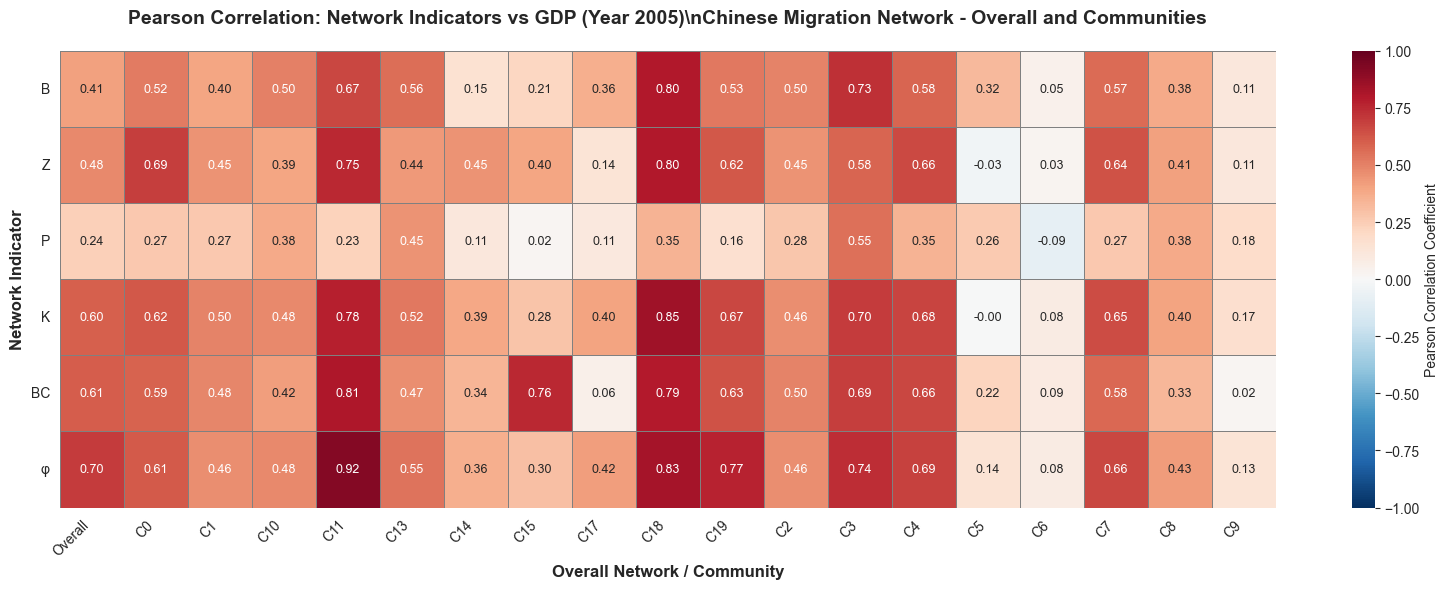

✓ Saved: correlation_heatmap_year_2005.png\n


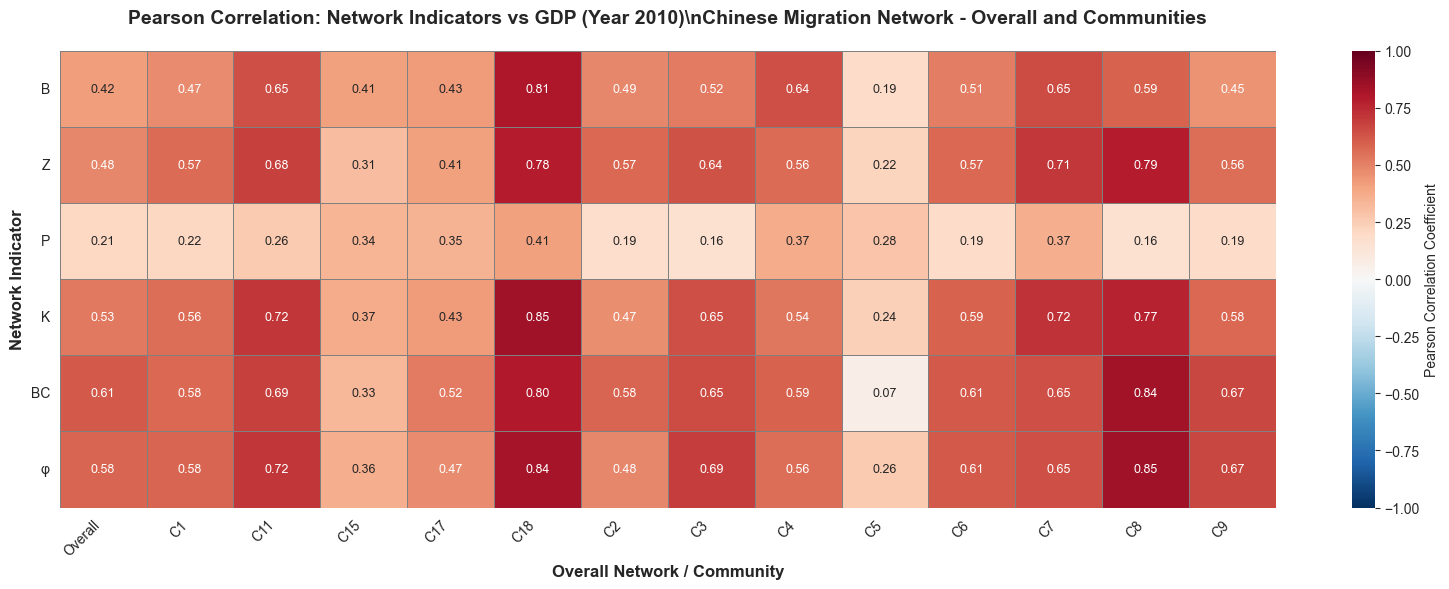

✓ Saved: correlation_heatmap_year_2010.png\n


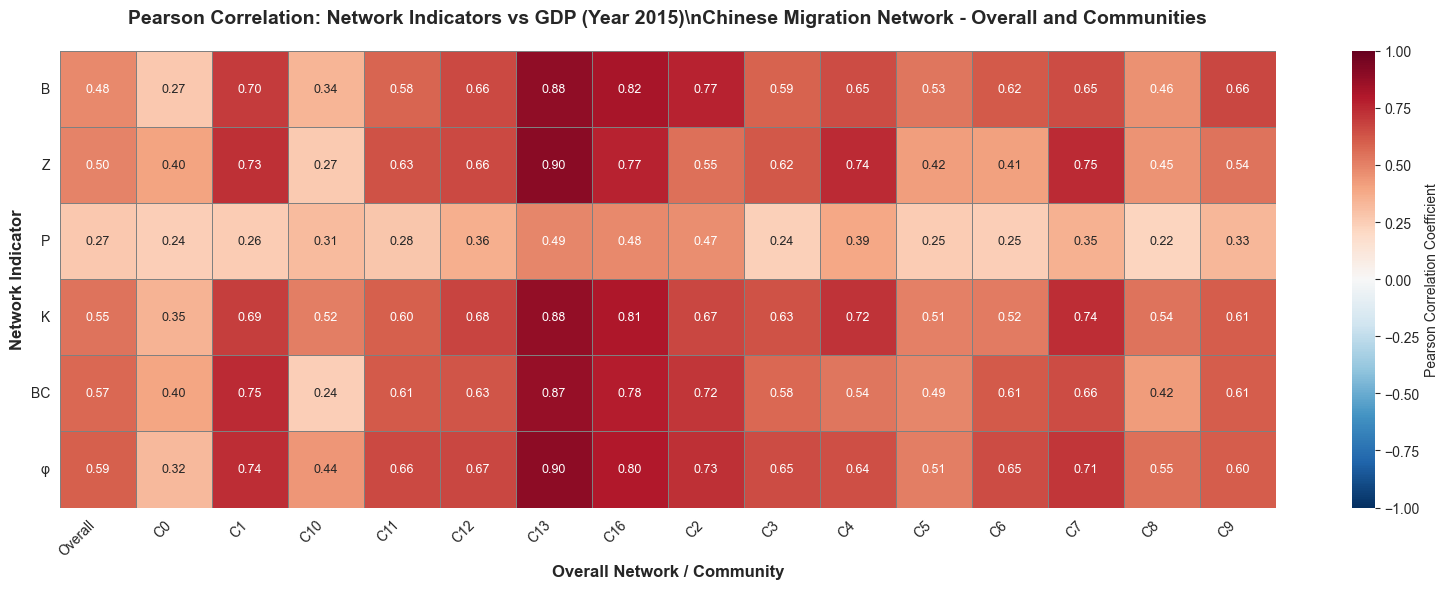

✓ Saved: correlation_heatmap_year_2015.png\n
✓ Heatmaps created for sample years


In [9]:
print("Creating correlation heatmaps for sample years...\\n")

# Function to create heatmap for a specific year
def create_heatmap_for_year(df_yearly_corr, year, indicators=['B', 'Z', 'P', 'K', 'BC', 'φ']):
    """Create correlation heatmap for a specific year"""
    year_data = df_yearly_corr[df_yearly_corr['year'] == year].copy()
    
    if len(year_data) == 0:
        return None
    
    # Build data matrix
    communities_list = sorted([c for c in year_data['community'].unique() if c != 'Overall'])
    columns = ['Overall'] + communities_list
    
    heatmap_data = []
    for abbrev in indicators:
        row_data = []
        for comm in columns:
            comm_row = year_data[year_data['community'] == comm]
            if len(comm_row) > 0:
                corr = comm_row.iloc[0].get(f'{abbrev}_corr', np.nan)
                row_data.append(corr)
            else:
                row_data.append(np.nan)
        heatmap_data.append(row_data)
    
    return pd.DataFrame(heatmap_data, index=indicators, columns=columns)


# Create heatmaps for sample years
sample_years = [2005, 2010, 2015]

for year in sample_years:
    heatmap_df = create_heatmap_for_year(df_yearly_corr, year)
    
    if heatmap_df is not None:
        fig, ax = plt.subplots(figsize=(16, 6))
        
        sns.heatmap(heatmap_df, annot=True, fmt='.2f', cmap='RdBu_r',
                    center=0, vmin=-1, vmax=1,
                    cbar_kws={'label': 'Pearson Correlation Coefficient'},
                    linewidths=0.5, linecolor='gray', ax=ax,
                    annot_kws={'size': 9})
        
        plt.title(f'Pearson Correlation: Network Indicators vs GDP (Year {year})\\n' +
                  'Chinese Migration Network - Overall and Communities',
                  fontsize=14, fontweight='bold', pad=20)
        plt.xlabel('Overall Network / Community', fontsize=12, fontweight='bold')
        plt.ylabel('Network Indicator', fontsize=12, fontweight='bold')
        plt.xticks(rotation=45, ha='right')
        plt.yticks(rotation=0)
        plt.tight_layout()
        
        filename = f'correlation_heatmap_year_{year}.png'
        plt.savefig(filename, dpi=300, bbox_inches='tight')
        plt.show()
        
        print(f"✓ Saved: {filename}\\n")

print("✓ Heatmaps created for sample years")

## 10. Temporal Evolution of Correlations

Track how correlations change over time for the overall network and specific communities.

Creating temporal evolution plots...\n


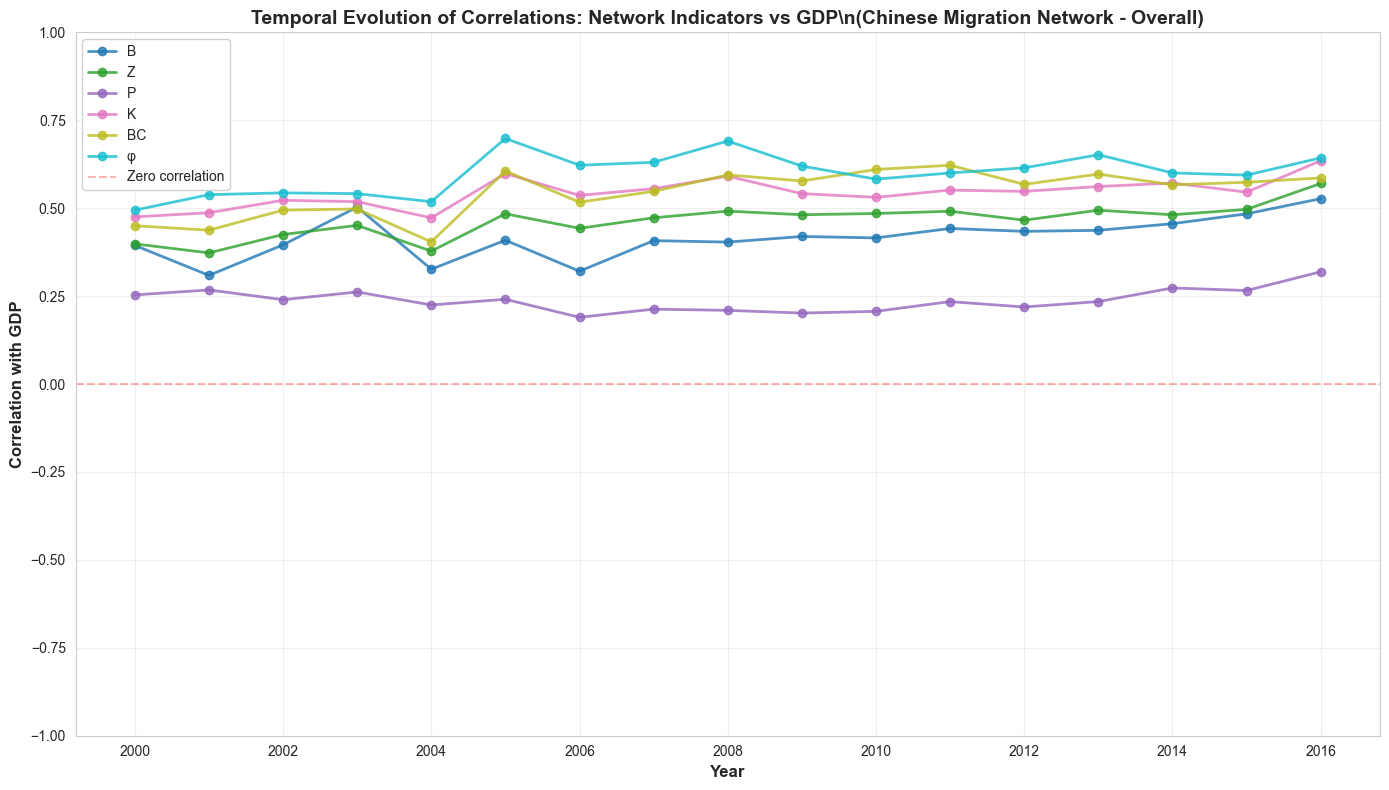

✓ Saved: correlation_temporal_evolution_overall.png\n
Temporal Evolution Summary (Overall Network):
B   : mean=0.417, std=0.060, min=0.309, max=0.527
Z   : mean=0.464, std=0.049, min=0.373, max=0.570
P   : mean=0.239, std=0.033, min=0.190, max=0.319
K   : mean=0.544, std=0.043, min=0.473, max=0.635
BC  : mean=0.544, std=0.066, min=0.404, max=0.622
φ   : mean=0.599, std=0.058, min=0.494, max=0.698
\n✓ Temporal evolution analysis complete


In [10]:
print("Creating temporal evolution plots...\\n")

# Filter to Overall Network only
df_overall_temporal = df_yearly_corr[df_yearly_corr['community'] == 'Overall'].copy()
df_overall_temporal = df_overall_temporal.sort_values('year')

# Plot main indicators
fig, ax = plt.subplots(figsize=(14, 8))

indicators_to_plot = ['B', 'Z', 'P', 'K', 'BC', 'φ']
colors = plt.cm.tab10(np.linspace(0, 1, len(indicators_to_plot)))

for idx, abbrev in enumerate(indicators_to_plot):
    col_name = f'{abbrev}_corr'
    if col_name in df_overall_temporal.columns:
        ax.plot(df_overall_temporal['year'], df_overall_temporal[col_name], 
               marker='o', linewidth=2, markersize=6, 
               color=colors[idx], label=abbrev, alpha=0.8)

ax.axhline(y=0, color='red', linestyle='--', alpha=0.3, label='Zero correlation')
ax.set_xlabel('Year', fontsize=12, fontweight='bold')
ax.set_ylabel('Correlation with GDP', fontsize=12, fontweight='bold')
ax.set_title('Temporal Evolution of Correlations: Network Indicators vs GDP\\n(Chinese Migration Network - Overall)', 
            fontsize=14, fontweight='bold')
ax.legend(loc='best', framealpha=0.9)
ax.grid(True, alpha=0.3)
ax.set_ylim(-1, 1)

plt.tight_layout()
plt.savefig('correlation_temporal_evolution_overall.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved: correlation_temporal_evolution_overall.png\\n")

# Summary statistics
print("Temporal Evolution Summary (Overall Network):")
print("="*80)
for abbrev in indicators_to_plot:
    col_name = f'{abbrev}_corr'
    if col_name in df_overall_temporal.columns:
        values = df_overall_temporal[col_name].dropna()
        print(f"{abbrev:4s}: mean={values.mean():.3f}, std={values.std():.3f}, " +
              f"min={values.min():.3f}, max={values.max():.3f}")

print("\\n✓ Temporal evolution analysis complete")

## 11. Year-by-Year Correlation Analysis

In [11]:
print("Calculating year-by-year correlations...\\n")

yearly_correlations = []

# Get available years
available_years = sorted([y for y in merged_data['year'].unique() if not np.isnan(y)])
print(f"Processing {len(available_years)} years...")
print(f"Year range: {min(available_years):.0f} - {max(available_years):.0f}\\n")

for year in available_years:
    year_data = merged_data[merged_data['year'] == year]
    
    # Overall Network for this year
    year_results = {'year': int(year), 'community': 'Overall'}
    
    for metric_key, abbrev in network_indicators.items():
        if metric_key in year_data.columns:
            corr, p_val, n = calculate_correlation(year_data, metric_key)
            year_results[f'{abbrev}_corr'] = corr
            year_results[f'{abbrev}_pval'] = p_val
            year_results[f'{abbrev}_n'] = n
    
    yearly_correlations.append(year_results)
    
    # By community for this year
    for community_id in communities:
        comm_year_data = year_data[year_data['community'] == community_id]
        
        # Skip if too few samples
        if len(comm_year_data) < 5:
            continue
        
        comm_year_results = {'year': int(year), 'community': f'C{community_id}'}
        
        for metric_key, abbrev in network_indicators.items():
            if metric_key in comm_year_data.columns:
                corr, p_val, n = calculate_correlation(comm_year_data, metric_key)
                comm_year_results[f'{abbrev}_corr'] = corr
                comm_year_results[f'{abbrev}_pval'] = p_val
                comm_year_results[f'{abbrev}_n'] = n
        
        yearly_correlations.append(comm_year_results)

# Create DataFrame
df_yearly_corr = pd.DataFrame(yearly_correlations)

print(f"✓ Calculated year-by-year correlations: {len(df_yearly_corr):,} rows")

# Save to CSV
df_yearly_corr.to_csv('correlation_network_gdp_yearly_by_community.csv', index=False)
print("✓ Saved: correlation_network_gdp_yearly_by_community.csv")

# Display sample (Overall, first 5 years)
print("\\nSample (Overall Network, first 5 years):")
overall_sample = df_yearly_corr[df_yearly_corr['community'] == 'Overall'].head()
display(overall_sample[['year', 'community', 'B_corr', 'Z_corr', 'P_corr', 'K_corr', 'BC_corr', 'φ_corr']])

Calculating year-by-year correlations...\n
Processing 17 years...
Year range: 2000 - 2016\n


NameError: name 'communities' is not defined

## 12. Temporal Evolution Visualization

Creating temporal evolution plot...\n


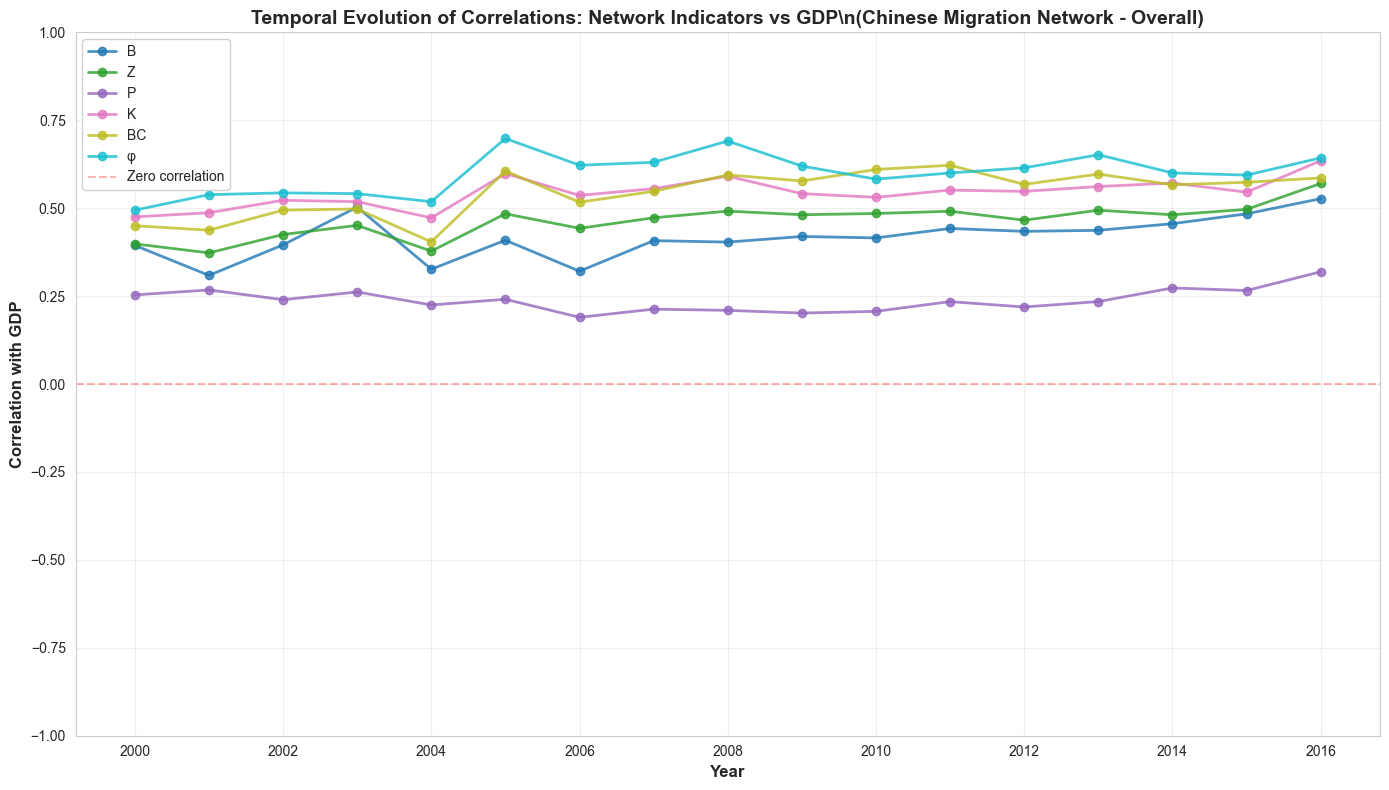

✓ Saved: correlation_temporal_evolution_overall.png


In [12]:
print("Creating temporal evolution plot...\\n")

# Filter to Overall Network only for cleaner visualization
df_overall_temporal = df_yearly_corr[df_yearly_corr['community'] == 'Overall'].copy()
df_overall_temporal = df_overall_temporal.sort_values('year')

# Plot main indicators
fig, ax = plt.subplots(figsize=(14, 8))

indicators_to_plot = ['B', 'Z', 'P', 'K', 'BC', 'φ']
colors = plt.cm.tab10(np.linspace(0, 1, len(indicators_to_plot)))

for idx, abbrev in enumerate(indicators_to_plot):
    col_name = f'{abbrev}_corr'
    if col_name in df_overall_temporal.columns:
        ax.plot(df_overall_temporal['year'], df_overall_temporal[col_name], 
               marker='o', linewidth=2, markersize=6, 
               color=colors[idx], label=abbrev, alpha=0.8)

ax.axhline(y=0, color='red', linestyle='--', alpha=0.3, label='Zero correlation')
ax.set_xlabel('Year', fontsize=12, fontweight='bold')
ax.set_ylabel('Correlation with GDP', fontsize=12, fontweight='bold')
ax.set_title('Temporal Evolution of Correlations: Network Indicators vs GDP\\n(Chinese Migration Network - Overall)', 
            fontsize=14, fontweight='bold')
ax.legend(loc='best', framealpha=0.9)
ax.grid(True, alpha=0.3)
ax.set_ylim(-1, 1)

plt.tight_layout()
plt.savefig('correlation_temporal_evolution_overall.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved: correlation_temporal_evolution_overall.png")

## Summary

### Analysis Context
This notebook analyzes the **Chinese Migration Network (1980-2016)** at the county level, examining correlations between network structural indicators and regional GDP.

**Important:** Communities are detected separately for each year using the Louvain algorithm (random seed = 8). Therefore, community labels (C1, C2, etc.) are **not consistent across years**. All correlations are calculated on a **year-by-year basis** to ensure meaningful results.

### Generated Files

**Main Correlation Data:**
1. `correlation_network_gdp_yearly_by_community.csv` - Complete year-by-year correlation data (long format)
2. `correlation_network_gdp_formatted_all_years.csv` - Formatted tables with significance markers for all years

**Visualizations:**
3. `correlation_heatmap_year_2005.png` - Heatmap for year 2005
4. `correlation_heatmap_year_2010.png` - Heatmap for year 2010  
5. `correlation_heatmap_year_2015.png` - Heatmap for year 2015
6. `correlation_temporal_evolution_overall.png` - Time series showing how correlations evolve over time

### Key Results

- **Network indicators analyzed**: 
  - B (gatewayness), Z (provincialness), P (connectorness)
  - K (degree), BC (betweenness centrality), φ (rich club coefficient)
  - Plus: C (closeness), PR (PageRank), E (eigenvector), CC (clustering)
  
- **Analysis approach**: Year-by-year correlations
  - Each year analyzed separately
  - Overall network (all communities combined) + individual migration communities
  - Communities change year-to-year, so correlations are not comparable across years
  
- **Significance testing**: ** for p < 0.001, * for p < 0.01

- **Temporal coverage**: Years with GDP data available (typically 2000-2016)

In [ ]:
print("="*80)
print("CORRELATION ANALYSIS COMPLETE")
print("Chinese Migration Network (1980-2016)")
print("="*80)
print("\\n✓ All tables and visualizations generated successfully")
print("\\n📊 Analysis Approach: Year-by-Year Correlations")
print("   Communities change annually, so each year is analyzed separately")
print("\\nOutput files:")
print("  Main Data:")
print("    - correlation_network_gdp_yearly_by_community.csv")
print("    - correlation_network_gdp_formatted_all_years.csv")
print("  Visualizations:")
print("    - correlation_heatmap_year_2005.png")
print("    - correlation_heatmap_year_2010.png")
print("    - correlation_heatmap_year_2015.png")
print("    - correlation_temporal_evolution_overall.png")
print("\\n✓ Ready for analysis and publication!")